# Cost-Weighted GEC DELCODE Whole-Brain Classifier with 5-Fold Stratified Cross-Validation

In [1]:
import sys
from pathlib import Path

model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(model_root))

print(f'Added to sys.path: {model_root}')

Added to sys.path: /mnt/e/fyassine/ad-early-detection/CLASSIFIER


In [2]:
import json
import numpy as np
import os
import torch
import wandb
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from torch_geometric.loader import DataLoader
from copy import deepcopy
from datetime import datetime

from common.dataset import ClassificationDataset, CombinedClassificationDataset
from model.CostWeightedGEC.models import GraphEncoderClassifierAttention
from common.utils import (
    load_frozen_encoder_from_gaae,
    compute_class_weights,
    compute_class_cost_weights,
    knn_binary_adjacency_matrix_no_diag,
    set_seed,
)
from model.CostWeightedGEC.train import train_classifier
from common.validation import run_kfold_cv

sns.set_theme(style='whitegrid')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [4]:
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = 'cost-weighted-gec-converter-classification-whole-brain'

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/wunderlich/.netrc.
wandb: Currently logged in as: lakhalfrajyassine (lakhalfrajyassine-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
WB_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata'
COHORTS_CSV = os.path.join(METADATA_DIR, 'cohorts.csv')
GEC_SPLITS_DIR = os.path.join(METADATA_DIR, 'splits_gec')
TRAIN_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'train.csv')
VAL_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'val.csv')

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints_gaae_whole_brain'),
]

CW_GEC_OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints_cost_weighted_gec_whole_brain')
os.makedirs(CW_GEC_OUTPUT_DIR, exist_ok=True)
CW_GEC_CHECKPOINT_SEARCH_DIRS = [CW_GEC_OUTPUT_DIR]
USE_CW_GEC_CHECKPOINT = False

IN_FEATURES = 400
HIDDEN_DIM = 400
LATENT_DIM = 32
COND_DIM = 2
NUM_HEADS = 2
DROPOUT = 0.5
CLASSIFIER_HIDDEN = 32

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 30
USE_SCHEDULER = True

USE_CLASS_COST_WEIGHTS = True
NORMALIZE_CLASS_COST_WEIGHTS = True

KNN_K = 8
adjacency_args = {'k': KNN_K}
CORRELATION_TYPE = 'whole_brain'
FILE_VARIANT = 'z_transformed'

FREEZE_ENCODER = False

N_FOLDS = 5
RANDOM_STATE = 42

In [6]:
set_seed(RANDOM_STATE)
print(f'Seed set to {RANDOM_STATE}')

Seed set to 42


In [7]:
checkpoint_candidates = sorted(
    [
        (run_dir.name, str(model_file), str(run_dir))
        for checkpoint_dir in CHECKPOINT_SEARCH_DIRS
        for base_dir in [Path(checkpoint_dir)]
        if base_dir.is_dir()
        for run_dir in sorted(base_dir.iterdir())
        if run_dir.is_dir()
        for model_file in [run_dir / f'model_{run_dir.name}.pth']
        if model_file.exists()
    ],
    key=lambda x: x[0],
)

if not checkpoint_candidates:
    raise FileNotFoundError('No GAAE checkpoints found. Train MODEL/notebooks/GAAE_DELCODE_WHOLE_BRAIN.ipynb first.')

print('Available GAAE checkpoints:')
for i, (run_name, _, run_dir) in enumerate(checkpoint_candidates):
    print(f'  {i}: {run_name} ({run_dir})')

default_index = len(checkpoint_candidates) - 1
selected_run_index_text = input(f'Select a GAAE checkpoint by index [default {default_index}]: ').strip()
selected_run_index = default_index if selected_run_index_text == '' else int(selected_run_index_text)
if selected_run_index < 0 or selected_run_index >= len(checkpoint_candidates):
    raise IndexError(f'GAAE checkpoint index out of range: {selected_run_index}')

RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

run_config_path = Path(SELECTED_RUN_DIR) / 'run_config.json'
if run_config_path.exists():
    with open(run_config_path, 'r') as f:
        run_config = json.load(f)
    model_cfg = run_config.get('model_config', {})
    IN_FEATURES = int(model_cfg.get('in_features', IN_FEATURES))
    HIDDEN_DIM = int(model_cfg.get('hidden_size', HIDDEN_DIM))
    LATENT_DIM = int(model_cfg.get('latent_dim', LATENT_DIM))
    NUM_HEADS = int(model_cfg.get('attention_heads', NUM_HEADS))
    DROPOUT = float(model_cfg.get('dropout', DROPOUT))
    print(f'Loaded run config from {run_config_path}')

print(f'Using GAAE checkpoint: {GAAE_CHECKPOINT_PATH}')
print(f'Configured dims: in={IN_FEATURES}, latent={LATENT_DIM}, heads={NUM_HEADS}, dropout={DROPOUT}')

mode_input = input('Select Cost-Weighted GEC mode: [1] use existing checkpoint, [2] train (default: 2): ').strip().lower()
if mode_input in {'', '2', 't', 'train'}:
    USE_CW_GEC_CHECKPOINT = False
elif mode_input in {'1', 'c', 'checkpoint'}:
    USE_CW_GEC_CHECKPOINT = True
else:
    raise ValueError('Invalid mode selection. Use 1/checkpoint or 2/train.')

print(f"Cost-Weighted GEC mode selected: {'checkpoint' if USE_CW_GEC_CHECKPOINT else 'train'}")

if USE_CW_GEC_CHECKPOINT:
    cw_checkpoint_candidates = sorted(
        [
            (run_dir.name, str(model_file), str(run_dir))
            for checkpoint_dir in CW_GEC_CHECKPOINT_SEARCH_DIRS
            for base_dir in [Path(checkpoint_dir)]
            if base_dir.is_dir()
            for run_dir in sorted(base_dir.iterdir())
            if run_dir.is_dir()
            for model_file in sorted(run_dir.glob('best_model_fold*.pth'))
        ],
        key=lambda x: x[0],
    )

    if not cw_checkpoint_candidates:
        raise FileNotFoundError('No Cost-Weighted GEC checkpoints found. Switch to training mode to create one.')

    print('Available Cost-Weighted GEC checkpoints:')
    for i, (run_name, model_file, run_dir) in enumerate(cw_checkpoint_candidates):
        print(f'  {i}: {run_name} ({model_file})')

    default_cw_index = len(cw_checkpoint_candidates) - 1
    selected_cw_index_text = input(f'Select a Cost-Weighted GEC checkpoint by index [default {default_cw_index}]: ').strip()
    selected_cw_index = default_cw_index if selected_cw_index_text == '' else int(selected_cw_index_text)
    if selected_cw_index < 0 or selected_cw_index >= len(cw_checkpoint_candidates):
        raise IndexError(f'Cost-Weighted GEC checkpoint index out of range: {selected_cw_index}')

    CW_GEC_RUN_NAME, CW_GEC_CHECKPOINT_PATH, CW_GEC_SELECTED_RUN_DIR = cw_checkpoint_candidates[selected_cw_index]
    run_artifact_dir = CW_GEC_SELECTED_RUN_DIR
    active_run_dir = Path(run_artifact_dir)
    print(f'Using Cost-Weighted GEC checkpoint: {CW_GEC_CHECKPOINT_PATH}')
    print(f'Using checkpoint artifact directory: {active_run_dir}')
else:
    CW_GEC_RUN_NAME = None
    CW_GEC_CHECKPOINT_PATH = None
    CW_GEC_SELECTED_RUN_DIR = None

Available GAAE checkpoints:
  0: worldly-plasma-2_2026-03-24_01-00-18 (/mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18)
Loaded run config from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/run_config.json
Using GAAE checkpoint: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth
Configured dims: in=200, latent=64, heads=2, dropout=0.3
Cost-Weighted GEC mode selected: train


In [8]:
if not os.path.exists(GAAE_CHECKPOINT_PATH):
    raise FileNotFoundError(f'Checkpoint not found: {GAAE_CHECKPOINT_PATH}')
print(f'Checkpoint ready: {GAAE_CHECKPOINT_PATH}')

Checkpoint ready: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_gaae_whole_brain/worldly-plasma-2_2026-03-24_01-00-18/model_worldly-plasma-2_2026-03-24_01-00-18.pth


## Load Datasets

In [9]:
split_paths = {
    'train': TRAIN_SPLIT_CSV,
    'val': VAL_SPLIT_CSV,
}
allowed_diagnoses = {'converter', 'mci'}

cohorts_df = pd.read_csv(COHORTS_CSV)
id_candidates = ['Repseudonym', 'Pseudonym', 'ID']
cohort_id_col = next((c for c in id_candidates if c in cohorts_df.columns), None)
if cohort_id_col is None:
    raise ValueError(
        f"Missing subject ID column in cohorts CSV. Expected one of {id_candidates}, found: {list(cohorts_df.columns)}"
    )
if 'diagnosis' not in cohorts_df.columns:
    raise ValueError(f"Missing 'diagnosis' column in cohorts CSV: {COHORTS_CSV}")

cohorts_df[cohort_id_col] = cohorts_df[cohort_id_col].astype(str)
cohorts_df['diagnosis'] = cohorts_df['diagnosis'].astype(str).str.lower().str.strip()
cohort_diag_map = cohorts_df.groupby(cohort_id_col)['diagnosis'].apply(lambda s: set(s)).to_dict()

split_frames = {}
base_required_cols = {'Repseudonym', 'sex', 'age', 'diagnosis'}
for name, path in split_paths.items():
    df = pd.read_csv(path)
    missing_base = base_required_cols - set(df.columns)
    assert not missing_base, f'Split {name}.csv missing columns: {missing_base}'

    df = df.copy()
    df['Repseudonym'] = df['Repseudonym'].astype(str)
    df['diagnosis'] = df['diagnosis'].astype(str).str.lower().str.strip()

    invalid_labels = sorted(set(df['diagnosis']) - allowed_diagnoses)
    if invalid_labels:
        raise ValueError(
            f"Split {name}.csv contains diagnoses outside {sorted(allowed_diagnoses)}: {invalid_labels}"
        )

    missing_in_cohorts = sorted(set(df['Repseudonym']) - set(cohort_diag_map.keys()))
    if missing_in_cohorts:
        raise ValueError(
            f"Split {name}.csv has IDs missing in cohorts.csv (first 10): {missing_in_cohorts[:10]}"
        )

    mismatched = [
        sid for sid, diag in zip(df['Repseudonym'], df['diagnosis'])
        if diag not in cohort_diag_map.get(sid, set())
    ]
    if mismatched:
        raise ValueError(
            f"Split {name}.csv has diagnosis not matched in cohorts.csv (first 10 IDs): {mismatched[:10]}"
        )

    df['converter_status'] = (df['diagnosis'] == 'converter').astype(int)
    split_frames[name] = df

for name, df in split_frames.items():
    counts = df['diagnosis'].value_counts().to_dict()
    n_subjects = int(df['Repseudonym'].nunique())
    if 'n_scans' in df.columns:
        total_scans_from_metadata = int(pd.to_numeric(df['n_scans'], errors='coerce').fillna(0).sum())
        print(
            f"{name}: subjects={n_subjects}, total_scans(metadata n_scans)={total_scans_from_metadata}, diagnosis_counts={counts}"
        )
    else:
        print(f"{name}: subjects={n_subjects}, diagnosis_counts={counts}")

all_splits_df = pd.concat(split_frames.values(), ignore_index=True)
all_splits_df = all_splits_df.drop_duplicates(subset=['Repseudonym'], keep='first')
all_splits_df['Repseudonym'] = all_splits_df['Repseudonym'].astype(str)

patient_info_df = all_splits_df[['Repseudonym', 'sex', 'age']].rename(columns={'Repseudonym': 'Pseudonym'}).set_index('Pseudonym')
converter_ids = sorted(all_splits_df.loc[all_splits_df['diagnosis'] == 'converter', 'Repseudonym'].unique())
non_converter_ids = sorted(all_splits_df.loc[all_splits_df['diagnosis'] == 'mci', 'Repseudonym'].unique())

import tempfile
patient_info_path = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False).name
patient_info_df.to_csv(patient_info_path)

converter_dataset = ClassificationDataset(
    root=WB_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

non_converter_dataset = ClassificationDataset(
    root=WB_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=non_converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

print(f'Converter dataset size: scans={len(converter_dataset)}, subjects={len(converter_ids)}')
print(f'Non-converter dataset size: scans={len(non_converter_dataset)}, subjects={len(non_converter_ids)}')

train: subjects=86, total_scans(metadata n_scans)=177, diagnosis_counts={'converter': 43, 'mci': 43}
val: subjects=16, total_scans(metadata n_scans)=46, diagnosis_counts={'converter': 8, 'mci': 8}
Converter dataset size: scans=196, subjects=51
Non-converter dataset size: scans=402, subjects=51


In [10]:
combined_dataset = CombinedClassificationDataset(converter_dataset, non_converter_dataset)
all_labels = combined_dataset.get_labels()

total_scans = int(len(combined_dataset))
total_subjects = int(len(set(converter_ids).union(set(non_converter_ids))))
converter_scans = int(sum(all_labels))
non_converter_scans = int(total_scans - converter_scans)
converter_subjects = int(len(converter_ids))
non_converter_subjects = int(len(non_converter_ids))

print('\nCombined dataset:')
print(f'  Total scans: {total_scans}')
print(f'  Total subjects: {total_subjects}')
print(f'  Converter scans: {converter_scans} ({(converter_scans / total_scans * 100) if total_scans else 0:.1f}%)')
print(f'  Non-converter scans: {non_converter_scans} ({(non_converter_scans / total_scans * 100) if total_scans else 0:.1f}%)')
print(f'  Converter subjects: {converter_subjects} ({(converter_subjects / total_subjects * 100) if total_subjects else 0:.1f}%)')
print(f'  Non-converter subjects: {non_converter_subjects} ({(non_converter_subjects / total_subjects * 100) if total_subjects else 0:.1f}%)')


Combined dataset:
  Total scans: 598
  Total subjects: 102
  Converter scans: 196 (32.8%)
  Non-converter scans: 402 (67.2%)
  Converter subjects: 51 (50.0%)
  Non-converter subjects: 51 (50.0%)


## Load Splits from Whole-Brain Metadata CSVs

Train + validation IDs form the cross-validation pool.

In [11]:
train_ids = set(split_frames['train']['Repseudonym'].astype(str))
val_ids = set(split_frames['val']['Repseudonym'].astype(str))

patient_to_indices = {}
index_to_patient = {}
for idx in range(len(combined_dataset)):
    patient_id = str(getattr(combined_dataset[idx], 'patient_id', ''))
    index_to_patient[idx] = patient_id
    patient_to_indices.setdefault(patient_id, []).append(idx)

def get_split_indices(patient_ids):
    indices = []
    for pid in patient_ids:
        indices.extend(patient_to_indices.get(str(pid), []))
    return sorted(indices)

train_split_indices = get_split_indices(train_ids)
val_split_indices = get_split_indices(val_ids)

cv_indices = train_split_indices + val_split_indices
cv_labels = [all_labels[i] for i in cv_indices]

train_subjects_with_scans = {index_to_patient[i] for i in train_split_indices if index_to_patient[i] != ''}
val_subjects_with_scans = {index_to_patient[i] for i in val_split_indices if index_to_patient[i] != ''}

train_converter_subjects = int(split_frames['train']['converter_status'].sum())
val_converter_subjects = int(split_frames['val']['converter_status'].sum())

cv_pos = int(sum(cv_labels))
cv_subject_ids = set(train_ids).union(set(val_ids))
cv_converter_subjects = int(train_converter_subjects + val_converter_subjects)

cv_scan_rate = (cv_pos / len(cv_labels) * 100) if cv_labels else 0.0
cv_subject_rate = (cv_converter_subjects / len(cv_subject_ids) * 100) if cv_subject_ids else 0.0

print('Whole-brain split sizes (subjects vs scans):')
print(
    f'  Train split: listed_subjects={len(train_ids)}, subjects_with_scans={len(train_subjects_with_scans)}, '
    f'scans={len(train_split_indices)}, converter_subjects={train_converter_subjects}'
)
print(
    f'  Validation split: listed_subjects={len(val_ids)}, subjects_with_scans={len(val_subjects_with_scans)}, '
    f'scans={len(val_split_indices)}, converter_subjects={val_converter_subjects}'
)

print(
    f'\nCV set: scans={len(cv_indices)}, subjects={len(cv_subject_ids)}, '
    f'converter_scans={cv_pos} ({cv_scan_rate:.1f}%), '
    f'converter_subjects={cv_converter_subjects} ({cv_subject_rate:.1f}%)'
)

Whole-brain split sizes (subjects vs scans):
  Train split: listed_subjects=86, subjects_with_scans=86, scans=177, converter_subjects=43
  Validation split: listed_subjects=16, subjects_with_scans=16, scans=46, converter_subjects=8

CV set: scans=223, subjects=102, converter_scans=172 (77.1%), converter_subjects=51 (50.0%)


## 5-Fold Stratified Cross-Validation

In [ ]:

cv_results = {
    'fold': [], 'val_auc': [], 'val_sensitivity': [], 'val_specificity': [], 
    'val_f1': [], 'best_threshold': [], 'best_epoch': [], 'pos_weight': [], 'class_cost_weights': []
}
cv_histories = {'train_loss': [], 'val_loss': []}

best_model_state = None
best_val_auc = 0.0
best_fold = -1
best_threshold_overall = 0.5
best_f1_threshold = 0.5
oof_preds = []
oof_targets = []

cv_patient_ids = [index_to_patient[i] for i in cv_indices]

if USE_CW_GEC_CHECKPOINT:
    if CW_GEC_CHECKPOINT_PATH is None:
        raise RuntimeError('Cost-Weighted GEC checkpoint mode is enabled but no checkpoint path was selected.')

    checkpoint_obj = torch.load(CW_GEC_CHECKPOINT_PATH, map_location=device)

    model = GraphEncoderClassifierAttention(
        in_features=IN_FEATURES,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        cond_dim=COND_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
        classifier_hidden=CLASSIFIER_HIDDEN,
    ).to(device)

    model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)
    if not FREEZE_ENCODER:
        model.unfreeze_encoder()

    if isinstance(checkpoint_obj, torch.nn.Module):
        model = checkpoint_obj.to(device)
        best_model_state = model.state_dict()
    elif isinstance(checkpoint_obj, dict):
        state_dict = checkpoint_obj.get('state_dict', checkpoint_obj.get('model_state_dict', checkpoint_obj))
        model.load_state_dict(state_dict)
        best_model_state = state_dict

    model.eval()
    best_model = model

    run_summary_path = Path(CW_GEC_SELECTED_RUN_DIR) / 'run_summary.json'
    cv_results_path = Path(CW_GEC_SELECTED_RUN_DIR) / 'cv_results.json'

    if run_summary_path.exists():
        with open(run_summary_path, 'r') as f:
            run_summary = json.load(f)

        loaded_cv_results = run_summary.get('cv_results', {})
        if isinstance(loaded_cv_results, dict):
            for key in cv_results.keys():
                values = loaded_cv_results.get(key)
                if isinstance(values, list):
                    cv_results[key] = values

        loaded_cv_histories = run_summary.get('cv_histories', {})
        if isinstance(loaded_cv_histories, dict):
            cv_histories['train_loss'] = loaded_cv_histories.get('train_loss', [])
            cv_histories['val_loss'] = loaded_cv_histories.get('val_loss', [])

        best_fold = int(run_summary.get('best_fold', best_fold))
        best_val_auc = float(run_summary.get('best_val_auc', best_val_auc))
        best_threshold_overall = float(run_summary.get('best_threshold', best_threshold_overall))
        best_f1_threshold = float(run_summary.get('best_f1_threshold', best_f1_threshold))
    elif cv_results_path.exists():
        with open(cv_results_path, 'r') as f:
            loaded_cv_results = json.load(f)
        if isinstance(loaded_cv_results, dict):
            for key in cv_results.keys():
                values = loaded_cv_results.get(key)
                if isinstance(values, list):
                    cv_results[key] = values

        if len(cv_results['val_auc']) > 0:
            val_auc_arr = np.array(cv_results['val_auc'], dtype=float)
            best_idx = int(np.argmax(val_auc_arr))
            best_val_auc = float(val_auc_arr[best_idx])
            best_fold = int(cv_results['fold'][best_idx]) if len(cv_results['fold']) > best_idx else best_fold

    print(f'Loaded Cost-Weighted GEC checkpoint from {CW_GEC_CHECKPOINT_PATH}')
    print('Cross-validation skipped because checkpoint mode is enabled')
else:
    config = {
        'N_FOLDS': N_FOLDS,
        'RANDOM_STATE': RANDOM_STATE,
        'BATCH_SIZE': BATCH_SIZE,
        'USE_CLASS_COST_WEIGHTS': USE_CLASS_COST_WEIGHTS,
        'NORMALIZE_CLASS_COST_WEIGHTS': NORMALIZE_CLASS_COST_WEIGHTS,
        'GAAE_CHECKPOINT_PATH': GAAE_CHECKPOINT_PATH,
        'FREEZE_ENCODER': FREEZE_ENCODER,
        'LEARNING_RATE': LEARNING_RATE,
        'EPOCHS': EPOCHS,
        'EARLY_STOPPING_PATIENCE': EARLY_STOPPING_PATIENCE,
        'WANDB_PROJECT': WANDB_PROJECT,
        'USE_SCHEDULER': USE_SCHEDULER,
    }

    model_kwargs = {
        'in_features': IN_FEATURES,
        'hidden_dim': HIDDEN_DIM,
        'latent_dim': LATENT_DIM,
        'cond_dim': COND_DIM,
        'num_heads': NUM_HEADS,
        'dropout': DROPOUT,
        'classifier_hidden': CLASSIFIER_HIDDEN,
    }

    cv_results, cv_histories, best_model_state, best_model, best_val_auc, best_fold, best_threshold_overall, best_f1_threshold, oof_preds, oof_targets = run_kfold_cv(
        model_class=GraphEncoderClassifierAttention,
        model_kwargs=model_kwargs,
        combined_dataset=combined_dataset,
        cv_indices=cv_indices,
        cv_labels=cv_labels,
        cv_patient_ids=cv_patient_ids,
        index_to_patient=index_to_patient,
        all_labels=all_labels,
        config=config,
        device=device
    )


## Cross-Validation Results Summary

In [13]:
print('\nCross-Validation Summary:')
print('=' * 60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print('-' * 60)

for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    values = cv_results[metric]
    print(f"{metric:<20} {np.mean(values):>10.4f} {np.std(values):>10.4f} {np.min(values):>10.4f} {np.max(values):>10.4f}")

print(f'\nBest model from Fold {best_fold} with AUC = {best_val_auc:.4f}')
print(f'Best threshold (Youden):    {best_threshold_overall:.4f}')
print(f'Best threshold (F1-optimal): {best_f1_threshold:.4f}')


Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.6955     0.0637     0.6286     0.8088
val_sensitivity          0.7900     0.1996     0.4091     0.9444
val_specificity          0.6897     0.1666     0.5000     1.0000
val_f1                   0.8172     0.1222     0.5806     0.9189

Best model from Fold 2 with AUC = 0.8088
Best threshold (Youden):    0.3082
Best threshold (F1-optimal): 0.0000


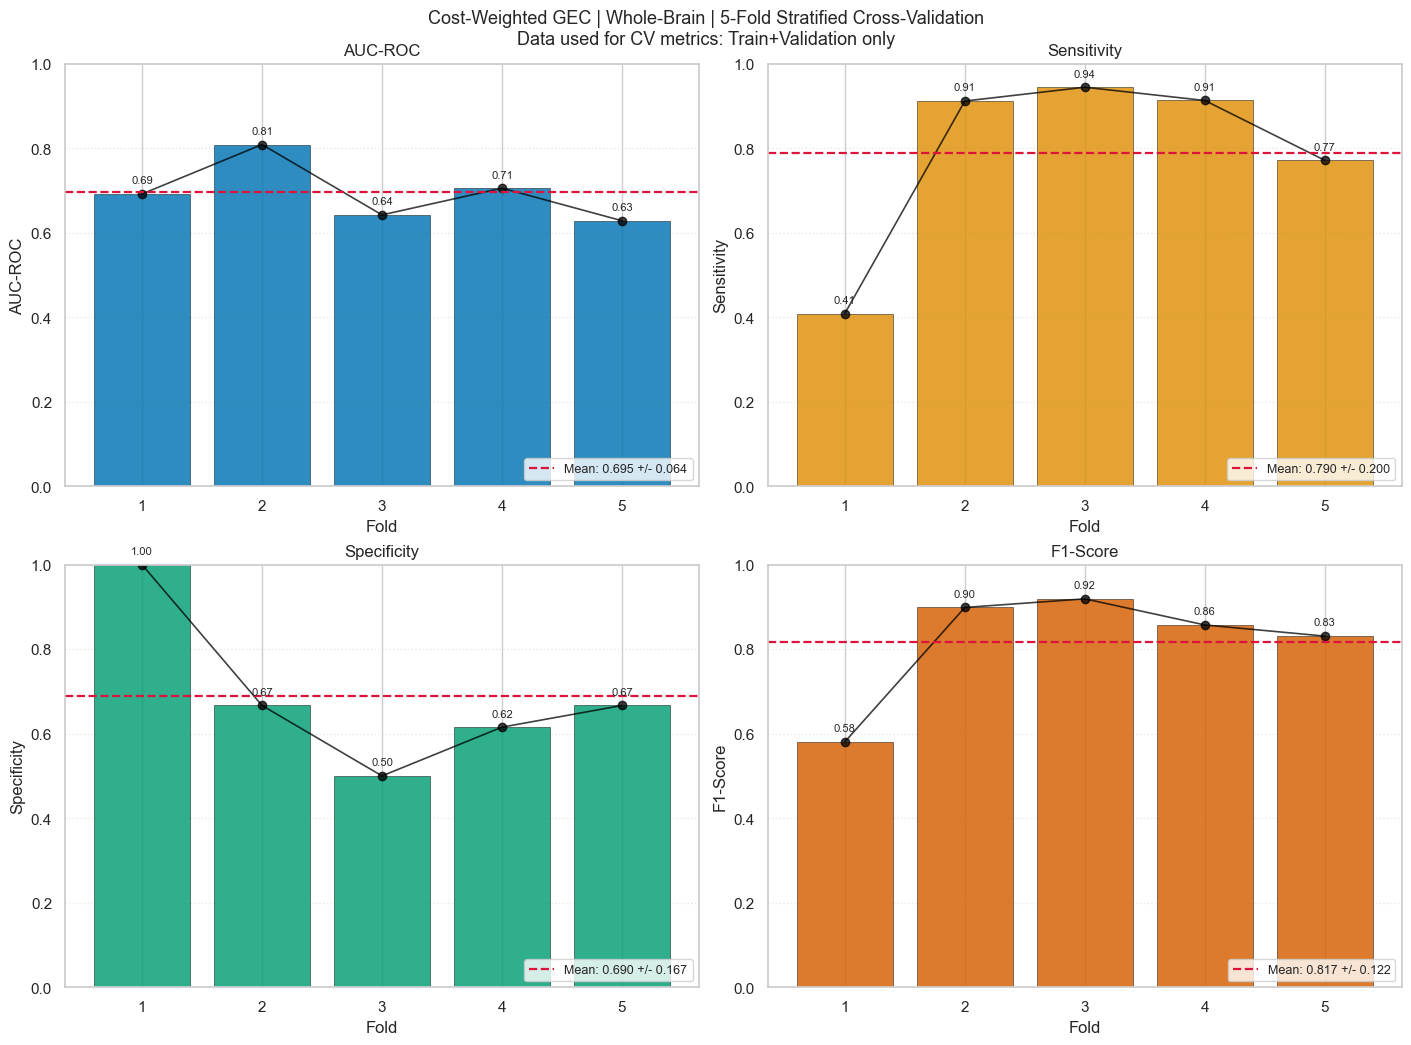

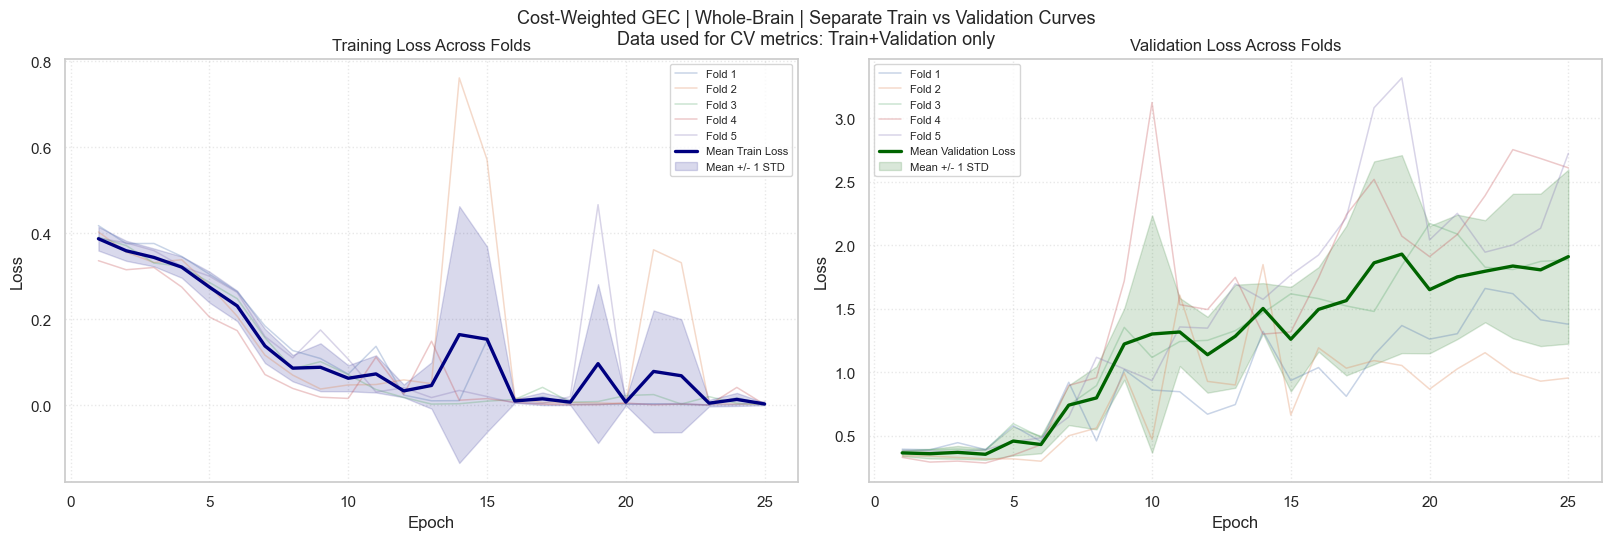

In [14]:
region_label = 'Whole-Brain' if str(CORRELATION_TYPE).lower() == 'whole_brain' else 'DMN-Only'
model_label = 'Cost-Weighted GEC'
data_scope_label = 'Data used for CV metrics: Train+Validation only'

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
titles = ['AUC-ROC', 'Sensitivity', 'Specificity', 'F1-Score']
colors = sns.color_palette('colorblind', len(metrics))

for ax, metric, title, color in zip(axes.flat, metrics, titles, colors):
    values = np.array(cv_results[metric], dtype=float)
    fold_x = np.arange(1, len(values) + 1)
    mean_val = float(np.mean(values))
    std_val = float(np.std(values))

    bars = ax.bar(fold_x, values, color=color, alpha=0.82, edgecolor='black', linewidth=0.4)
    ax.plot(fold_x, values, color='black', marker='o', linewidth=1.2, alpha=0.75)
    ax.axhline(y=mean_val, color='crimson', linestyle='--', linewidth=1.6, label=f'Mean: {mean_val:.3f} +/- {std_val:.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_xticks(fold_x)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle=':', alpha=0.45)
    ax.legend(loc='lower right', fontsize=9)

    for rect, val in zip(bars, values):
        ax.text(rect.get_x() + rect.get_width() / 2.0, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle(
    f'{model_label} | {region_label} | 5-Fold Stratified Cross-Validation\n{data_scope_label}',
    fontsize=13,
    y=1.03,
)
plt.show()

train_histories = [np.array(h, dtype=float) for h in cv_histories.get('train_loss', []) if len(h) > 0]
val_histories = [np.array(h, dtype=float) for h in cv_histories.get('val_loss', []) if len(h) > 0]

if train_histories and val_histories:
    max_train_len = max(len(h) for h in train_histories)
    max_val_len = max(len(h) for h in val_histories)

    train_mat = np.full((len(train_histories), max_train_len), np.nan, dtype=float)
    val_mat = np.full((len(val_histories), max_val_len), np.nan, dtype=float)

    for i, h in enumerate(train_histories):
        train_mat[i, :len(h)] = h
    for i, h in enumerate(val_histories):
        val_mat[i, :len(h)] = h

    train_mean = np.nanmean(train_mat, axis=0)
    train_std = np.nanstd(train_mat, axis=0)
    val_mean = np.nanmean(val_mat, axis=0)
    val_std = np.nanstd(val_mat, axis=0)

    epoch_train = np.arange(1, max_train_len + 1)
    epoch_val = np.arange(1, max_val_len + 1)

    fig2, ax2 = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    for fold_i, h in enumerate(train_histories, start=1):
        ax2[0].plot(np.arange(1, len(h) + 1), h, alpha=0.3, linewidth=1.1, label=f'Fold {fold_i}' if fold_i <= 5 else None)
    ax2[0].plot(epoch_train, train_mean, color='navy', linewidth=2.4, label='Mean Train Loss')
    ax2[0].fill_between(epoch_train, train_mean - train_std, train_mean + train_std, color='navy', alpha=0.15, label='Mean +/- 1 STD')
    ax2[0].set_title('Training Loss Across Folds')
    ax2[0].set_xlabel('Epoch')
    ax2[0].set_ylabel('Loss')
    ax2[0].grid(linestyle=':', alpha=0.45)
    ax2[0].legend(fontsize=8)

    for fold_i, h in enumerate(val_histories, start=1):
        ax2[1].plot(np.arange(1, len(h) + 1), h, alpha=0.3, linewidth=1.1, label=f'Fold {fold_i}' if fold_i <= 5 else None)
    ax2[1].plot(epoch_val, val_mean, color='darkgreen', linewidth=2.4, label='Mean Validation Loss')
    ax2[1].fill_between(epoch_val, val_mean - val_std, val_mean + val_std, color='darkgreen', alpha=0.15, label='Mean +/- 1 STD')
    ax2[1].set_title('Validation Loss Across Folds')
    ax2[1].set_xlabel('Epoch')
    ax2[1].set_ylabel('Loss')
    ax2[1].grid(linestyle=':', alpha=0.45)
    ax2[1].legend(fontsize=8)

    fig2.suptitle(
        f'{model_label} | {region_label} | Separate Train vs Validation Curves\n{data_scope_label}',
        fontsize=13,
        y=1.05,
    )
    plt.show()
else:
    print('No train/validation history found. Run cross-validation cell before plotting loss curves.')

In [ ]:
# ── THRESHOLD METHOD SELECTION ───────────────────────────────────────────────
import numpy as np
from sklearn.metrics import confusion_matrix

_oof_preds_arr = np.array(oof_preds)
_oof_targets_arr = np.array(oof_targets)

def _oof_metrics(thr):
    preds = (_oof_preds_arr >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(_oof_targets_arr, preds).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1   = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
    return sens, spec, f1

y_sens, y_spec, y_f1 = _oof_metrics(best_threshold_overall)
f_sens, f_spec, f_f1 = _oof_metrics(best_f1_threshold)

print('OOF threshold options:')
print(f'  [1] Youden\'s J   thr={best_threshold_overall:.4f}  '
      f'sens={y_sens:.3f}  spec={y_spec:.3f}  F1={y_f1:.3f}')
print(f'  [2] Best F1      thr={best_f1_threshold:.4f}  '
      f'sens={f_sens:.3f}  spec={f_spec:.3f}  F1={f_f1:.3f}')
print()

threshold_choice = input('Select threshold method [1=Youden (default), 2=Best F1]: ').strip()

if threshold_choice == '2':
    ACTIVE_THRESHOLD = float(best_f1_threshold)
    THRESHOLD_METHOD = 'oof_f1'
    print(f'Using F1-optimal threshold: {ACTIVE_THRESHOLD:.4f}')
else:
    ACTIVE_THRESHOLD = float(best_threshold_overall)
    THRESHOLD_METHOD = 'oof_youden'
    print(f'Using Youden threshold: {ACTIVE_THRESHOLD:.4f}')


## Save Best Model and Results

In [15]:
if USE_CW_GEC_CHECKPOINT:
    if CW_GEC_SELECTED_RUN_DIR is None:
        raise RuntimeError('Cost-Weighted GEC checkpoint mode is enabled but no checkpoint run directory was selected.')
    run_artifact_dir = str(CW_GEC_SELECTED_RUN_DIR)
    active_run_dir = Path(run_artifact_dir)
    run_name = active_run_dir.name
    print(f'Checkpoint mode active. Reusing existing run directory: {run_artifact_dir}')
else:
    if best_model_state is None:
        raise RuntimeError('No trained Cost-Weighted GEC model state found to save. Run training first.')

    run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    try:
        wandb_run_name = wandb.run.name if wandb and wandb.run and wandb.run.name else 'cv_run'
    except Exception:
        wandb_run_name = 'cv_run'
    wandb_run_name = str(wandb_run_name).replace(' ', '-')
    run_name = f'{wandb_run_name}_{run_timestamp}'

    run_artifact_dir = os.path.join(CW_GEC_OUTPUT_DIR, run_name)
    os.makedirs(run_artifact_dir, exist_ok=True)
    active_run_dir = Path(run_artifact_dir)

    model_filename = f'best_model_fold{best_fold}.pth'
    model_file = os.path.join(run_artifact_dir, model_filename)
    torch.save(best_model_state, model_file)
    print(f'Saved best model to {model_file}')

    results_file = os.path.join(run_artifact_dir, 'cv_results.json')
    with open(results_file, 'w') as f:
        json.dump(cv_results, f, indent=2)
    print(f'Saved CV results to {results_file}')

    run_summary = {
        'run_name': run_name,
        'timestamp': run_timestamp,
        'n_folds': N_FOLDS,
        'best_fold': int(best_fold),
        'best_val_auc': float(best_val_auc),
        'best_threshold': float(ACTIVE_THRESHOLD),
        'threshold_method': THRESHOLD_METHOD,
        'youden_threshold': float(best_threshold_overall),
        'f1_threshold': float(best_f1_threshold),
        'best_f1_threshold': float(best_f1_threshold),
        'threshold_method': THRESHOLD_METHOD,
        'cv_results': cv_results,
        'cv_histories': {
            'train_loss': cv_histories.get('train_loss', []),
            'val_loss': cv_histories.get('val_loss', []),
        },
        'config': {
            'in_features': IN_FEATURES,
            'hidden_dim': HIDDEN_DIM,
            'latent_dim': LATENT_DIM,
            'cond_dim': COND_DIM,
            'num_heads': NUM_HEADS,
            'dropout': DROPOUT,
            'classifier_hidden': CLASSIFIER_HIDDEN,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'epochs': EPOCHS,
            'early_stopping_patience': EARLY_STOPPING_PATIENCE,
            'knn_k': KNN_K,
            'file_variant': FILE_VARIANT,
            'correlation_type': CORRELATION_TYPE,
            'freeze_encoder': FREEZE_ENCODER,
            'gaae_checkpoint': GAAE_CHECKPOINT_PATH,
            'wb_root': WB_ROOT,
            'use_scheduler': USE_SCHEDULER,
            'use_class_cost_weights': USE_CLASS_COST_WEIGHTS,
            'normalize_class_cost_weights': NORMALIZE_CLASS_COST_WEIGHTS,
        },
    }
    summary_file = os.path.join(run_artifact_dir, 'run_summary.json')
    with open(summary_file, 'w') as f:
        json.dump(run_summary, f, indent=2)
    print(f'Saved run summary to {summary_file}')
    print(f'Active threshold ({THRESHOLD_METHOD}): {ACTIVE_THRESHOLD:.4f}')

print(f'Active artifact directory: {active_run_dir}')

Saved best model to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-05-06_19-47-47/best_model_fold2.pth
Saved CV results to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-05-06_19-47-47/cv_results.json
Saved run summary to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-05-06_19-47-47/run_summary.json
OOF Youden threshold saved: 0.3082
Active artifact directory: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-05-06_19-47-47


## Robustness Evaluation (Threshold from Reconstruction Error)

Using OOF Youden threshold: 0.308157
Top-5 correctly predicted samples closest to decision boundary (both classes):
 DatasetIndex PatientID  Probability  TrueLabel  AbsMargin
          407 849bda713     0.290083          0   0.018074
          136 b56914910     0.339104          1   0.030948
          142 b7366d4e7     0.380483          1   0.072326
          157 bc177df98     0.405504          1   0.097347
            5 05595022c     0.407512          1   0.099355

Class distribution in selected: {1: np.int64(4), 0: np.int64(1)}
Threshold: 0.3082   Prob range: [0.2901, 0.4075]


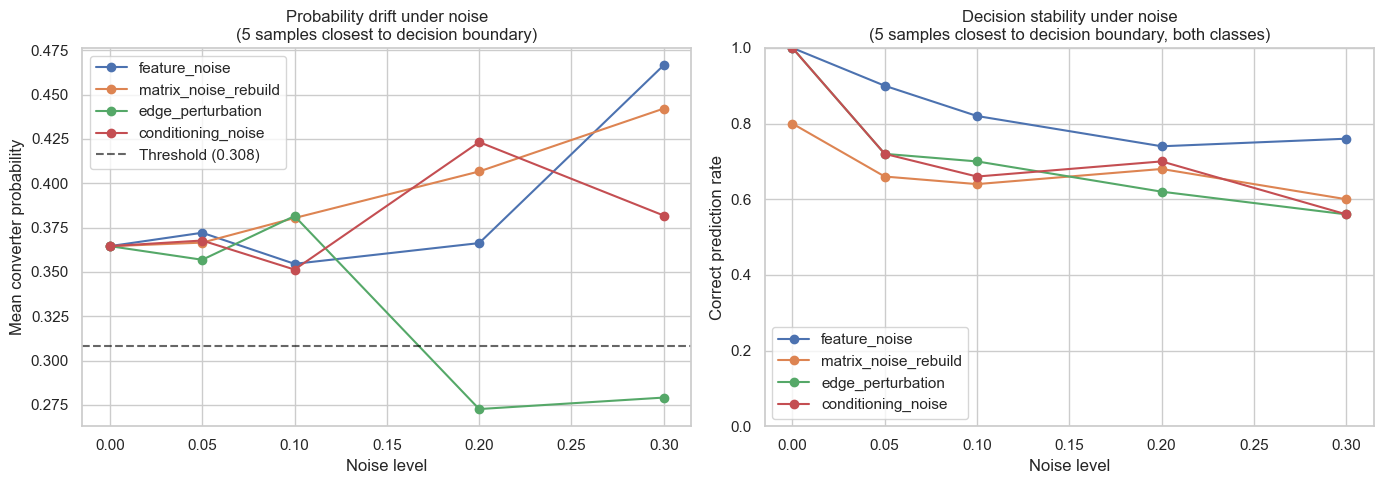

Saved evaluation artifacts to: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-05-06_19-47-47/robustness_eval_2026-05-06_19-47-54


In [16]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

np.random.seed(42)
torch.manual_seed(42)

if 'best_model_state' not in globals() or best_model_state is None:
    raise RuntimeError('best_model_state is missing. Run cross-validation training first.')

if 'GraphEncoderClassifierAttention' not in globals():
    raise RuntimeError('GraphEncoderClassifierAttention is missing. Run imports first.')

if 'cv_indices' not in globals() or 'all_labels' not in globals() or 'combined_dataset' not in globals():
    raise RuntimeError('CV data variables are missing. Run split and dataset cells first.')

if 'best_threshold_overall' not in globals():
    raise RuntimeError('best_threshold_overall is missing. Run cross-validation training first.')

eval_model = GraphEncoderClassifierAttention(
    in_features=IN_FEATURES,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    cond_dim=COND_DIM,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    classifier_hidden=CLASSIFIER_HIDDEN,
).to(device)
eval_model.load_state_dict(best_model_state)
eval_model.eval()

eval_threshold = float(best_threshold_overall)
print(f'Using OOF Youden threshold: {eval_threshold:.6f}')


def clone_sample(sample):
    cloned = sample.clone()
    if hasattr(cloned, 'x') and torch.is_tensor(cloned.x):
        cloned.x = cloned.x.clone()
    if hasattr(cloned, 'edge_index') and torch.is_tensor(cloned.edge_index):
        cloned.edge_index = cloned.edge_index.clone()
    if hasattr(cloned, 'edge_attr') and torch.is_tensor(cloned.edge_attr):
        cloned.edge_attr = cloned.edge_attr.clone()
    return cloned


def infer_probability(sample, noise_method='none', noise_level=0.0):
    d = clone_sample(sample)
    if noise_method in {'feature_noise', 'matrix_noise_rebuild'} and noise_level > 0:
        base_std = float(d.x.std().item()) if d.x.numel() > 1 else 1.0
        d.x = d.x + torch.randn_like(d.x) * (base_std * noise_level)
    if noise_method == 'matrix_noise_rebuild':
        adj_bin = knn_binary_adjacency_matrix_no_diag(d.x.detach().cpu().numpy(), **adjacency_args)
        src, dst = np.where(adj_bin > 0)
        if len(src) == 0:
            src = np.arange(max(0, d.x.size(0) - 1))
            dst = src + 1
        edge_index = np.vstack([src, dst])
        d.edge_index = torch.tensor(edge_index, dtype=torch.long)
    if noise_method == 'edge_perturbation' and noise_level > 0:
        edge_index = d.edge_index.detach().cpu()
        num_edges = edge_index.size(1)
        keep = max(1, int(round(num_edges * (1.0 - noise_level))))
        keep_perm = torch.randperm(num_edges)[:keep]
        kept_edges = edge_index[:, keep_perm]
        add_count = int(round(num_edges * noise_level))
        n_nodes = d.x.size(0)
        if add_count > 0:
            new_src = torch.randint(0, n_nodes, (add_count,), dtype=torch.long)
            new_dst = torch.randint(0, n_nodes, (add_count,), dtype=torch.long)
            valid = new_src != new_dst
            new_src = new_src[valid]
            new_dst = new_dst[valid]
            if new_src.numel() > 0:
                add_edges = torch.stack([new_src, new_dst], dim=0)
                d.edge_index = torch.cat([kept_edges, add_edges], dim=1)
            else:
                d.edge_index = kept_edges
        else:
            d.edge_index = kept_edges

    age = float(d.patient_age.item()) if torch.is_tensor(d.patient_age) else float(d.patient_age)
    sex = float(d.patient_sex.item()) if torch.is_tensor(d.patient_sex) else float(d.patient_sex)
    if noise_method == 'conditioning_noise' and noise_level > 0:
        age = age + float(np.random.normal(0.0, noise_level * 5.0))
        sex = float(np.clip(sex + np.random.normal(0.0, noise_level * 0.5), 0.0, 1.0))

    d = d.to(device)
    cond_vec = torch.tensor([[age, sex]], dtype=torch.float32, device=device)
    batch_mask = torch.zeros(d.x.size(0), dtype=torch.long, device=device)

    with torch.no_grad():
        logits, _ = eval_model(d.x, d.edge_index, cond_vec, batch_mask)
    prob = float(torch.sigmoid(logits).view(-1)[0].item())
    pred = int(prob >= eval_threshold)
    return prob, pred


# Select top-5 correctly predicted samples from BOTH classes with
# smallest absolute distance to the decision boundary.  Selecting
# only non-converters (as before) produced samples with prob ≈ 0.29
# when the threshold is ≈ 0.685 — a gap of ~0.40 that no noise level
# tested can bridge, causing the flat lines in the robustness plots.
baseline_rows = []
for idx in cv_indices:
    sample = combined_dataset[idx]
    true_label = int(all_labels[idx])
    prob, pred = infer_probability(sample, noise_method='none', noise_level=0.0)
    if pred == true_label:
        patient_id = str(getattr(sample, 'patient_id', f'idx_{idx}'))
        baseline_rows.append({
            'DatasetIndex': int(idx),
            'PatientID': patient_id,
            'Probability': float(prob),
            'TrueLabel': int(true_label),
            'AbsMargin': float(abs(prob - eval_threshold)),
        })

baseline_df = pd.DataFrame(baseline_rows)
if baseline_df.empty:
    raise RuntimeError('No correctly predicted samples found at baseline.')

selected_df = baseline_df.sort_values('AbsMargin', ascending=True).head(5)
print('Top-5 correctly predicted samples closest to decision boundary (both classes):')
print(selected_df.to_string(index=False))
print(f'\nClass distribution in selected: {dict(selected_df["TrueLabel"].value_counts())}')
print(f'Threshold: {eval_threshold:.4f}   Prob range: [{selected_df["Probability"].min():.4f}, {selected_df["Probability"].max():.4f}]')

noise_levels = [0.00, 0.05, 0.10, 0.20, 0.30]
n_trials = 10
noise_methods = ['feature_noise', 'matrix_noise_rebuild', 'edge_perturbation', 'conditioning_noise']

records = []
for _, row in selected_df.iterrows():
    ds_idx = int(row['DatasetIndex'])
    base_sample = combined_dataset[ds_idx]
    patient_id = str(row['PatientID'])
    true_label = int(row['TrueLabel'])
    for method in noise_methods:
        for noise_level in noise_levels:
            for trial in range(n_trials):
                prob, pred = infer_probability(base_sample, noise_method=method, noise_level=float(noise_level))
                correct = int(pred == true_label)
                records.append({
                    'PatientID': patient_id,
                    'DatasetIndex': ds_idx,
                    'TrueLabel': true_label,
                    'Method': method,
                    'NoiseLevel': float(noise_level),
                    'Trial': trial,
                    'Probability': float(prob),
                    'CorrectPrediction': correct,
                })

robustness_df = pd.DataFrame(records)
summary_df = (
    robustness_df
    .groupby(['Method', 'NoiseLevel'], as_index=False)
    .agg(
        MeanProbability=('Probability', 'mean'),
        StdProbability=('Probability', 'std'),
        CorrectRate=('CorrectPrediction', 'mean'),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in noise_methods:
    m = summary_df[summary_df['Method'] == method]
    axes[0].plot(m['NoiseLevel'], m['MeanProbability'], marker='o', label=method)
axes[0].axhline(eval_threshold, linestyle='--', color='black', alpha=0.6, label=f'Threshold ({eval_threshold:.3f})')
axes[0].set_xlabel('Noise level')
axes[0].set_ylabel('Mean converter probability')
axes[0].set_title('Probability drift under noise\n(5 samples closest to decision boundary)')
axes[0].legend()

for method in noise_methods:
    m = summary_df[summary_df['Method'] == method]
    axes[1].plot(m['NoiseLevel'], m['CorrectRate'], marker='o', label=method)
axes[1].set_xlabel('Noise level')
axes[1].set_ylabel('Correct prediction rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('Decision stability under noise\n(5 samples closest to decision boundary, both classes)')
axes[1].legend()

plt.tight_layout()
plt.show()

base_dir = Path(run_artifact_dir) if 'run_artifact_dir' in globals() else Path.cwd()
eval_dir = base_dir / f'robustness_eval_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
eval_dir.mkdir(parents=True, exist_ok=True)

selected_df.to_csv(eval_dir / 'selected_boundary_samples.csv', index=False)
summary_df.to_csv(eval_dir / 'robustness_summary.csv', index=False)
robustness_df.to_csv(eval_dir / 'robustness_details.csv', index=False)

meta = {
    'threshold_method': 'oof_youden',
    'threshold': eval_threshold,
    'sample_selection': 'abs_closest_to_boundary_both_classes',
    'noise_levels': noise_levels,
    'n_trials': n_trials,
    'methods': noise_methods,
    'selected_count': int(len(selected_df)),
    'source_set': 'cv_pool',
}
with open(eval_dir / 'robustness_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved evaluation artifacts to: {eval_dir}')

## Per-Class Robustness Evaluation

Selects the top-5 correctly predicted **converters** and top-5 **non-converters** closest to the decision boundary and evaluates noise robustness for each group separately.

Selected converters (n=5):
 DatasetIndex PatientID  Probability  TrueLabel  AbsMargin
          136 b56914910     0.339104          1   0.030948
          142 b7366d4e7     0.380483          1   0.072326
          157 bc177df98     0.405504          1   0.097347
            5 05595022c     0.407512          1   0.099355
            2 03a0a6663     0.413936          1   0.105779

Selected non-converters (n=5):
 DatasetIndex PatientID  Probability  TrueLabel  AbsMargin
          407 849bda713     0.290083          0   0.018074
          329 54e0f059e     0.009226          0   0.298931
          377 74816bbba     0.008543          0   0.299613
          562 e6b521171     0.002229          0   0.305928
          551 df57b92f6     0.001792          0   0.306365


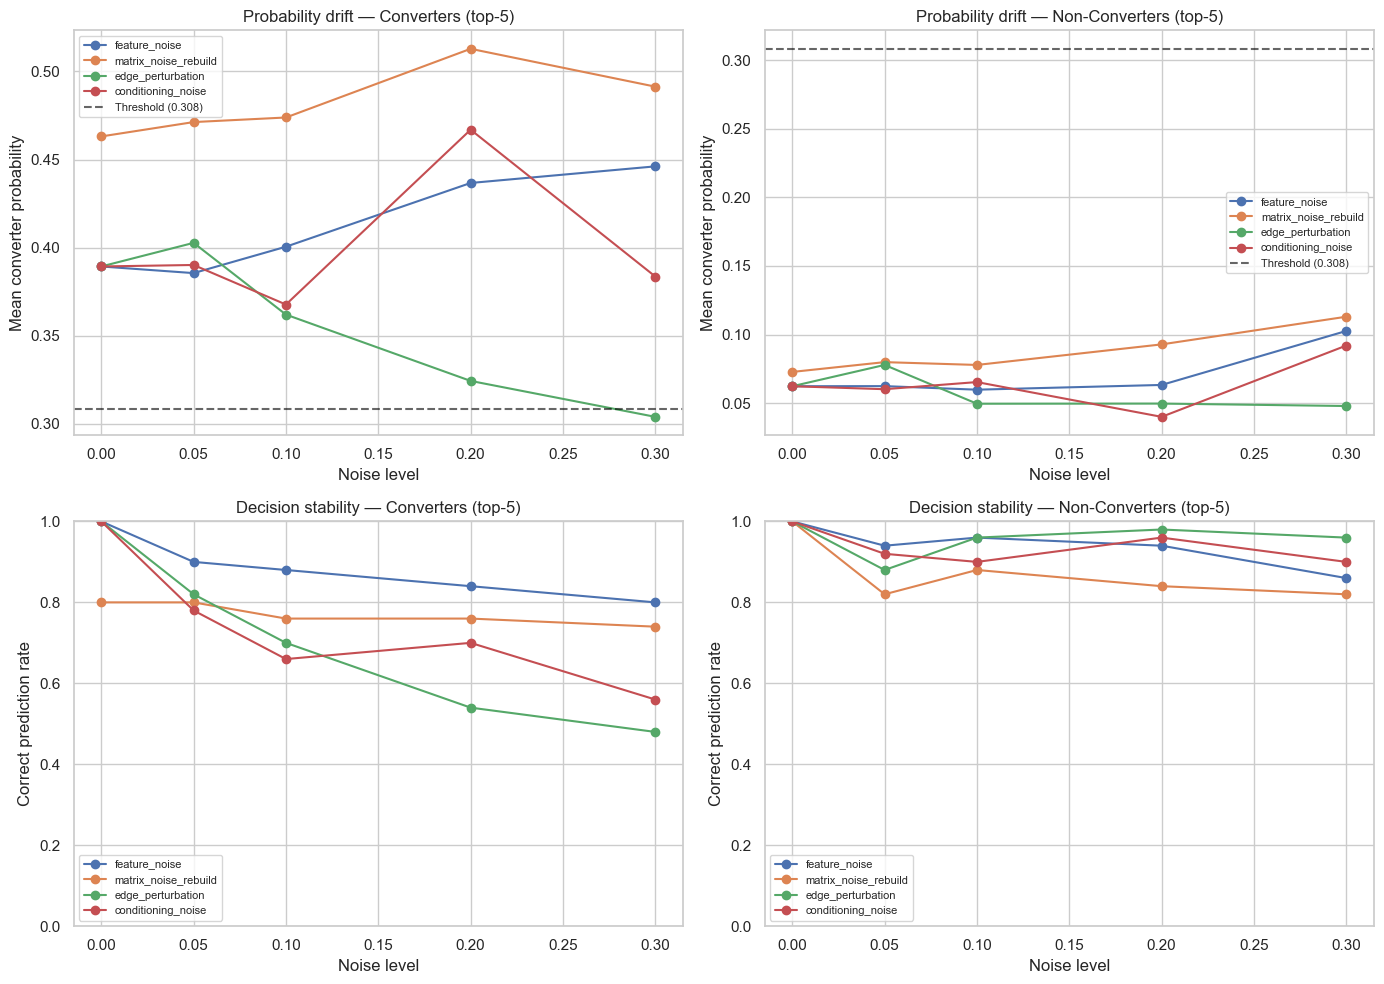

Saved per-class evaluation artifacts to: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints_cost_weighted_gec_whole_brain/cv_run_2026-05-06_19-47-47/robustness_per_class_2026-05-06_19-48-06


In [17]:
# Per-class robustness: top-5 converters and top-5 non-converters
# Uses eval_model, eval_threshold, infer_probability, and baseline_df from the previous cell.

np.random.seed(42)
torch.manual_seed(42)

if 'baseline_df' not in globals() or baseline_df.empty:
    raise RuntimeError('baseline_df is missing. Run the robustness evaluation cell first.')

selected_converters = (
    baseline_df[baseline_df['TrueLabel'] == 1]
    .sort_values('AbsMargin', ascending=True)
    .head(5)
)
selected_nonconverters = (
    baseline_df[baseline_df['TrueLabel'] == 0]
    .sort_values('AbsMargin', ascending=True)
    .head(5)
)

print(f'Selected converters (n={len(selected_converters)}):')
print(selected_converters.to_string(index=False))
print(f'\nSelected non-converters (n={len(selected_nonconverters)}):')
print(selected_nonconverters.to_string(index=False))

per_class_records = []
for group_name, group_df in [('converter', selected_converters), ('non_converter', selected_nonconverters)]:
    for _, row in group_df.iterrows():
        ds_idx = int(row['DatasetIndex'])
        base_sample = combined_dataset[ds_idx]
        patient_id = str(row['PatientID'])
        true_label = int(row['TrueLabel'])
        for method in noise_methods:
            for noise_level in noise_levels:
                for trial in range(n_trials):
                    prob, pred = infer_probability(base_sample, noise_method=method, noise_level=float(noise_level))
                    correct = int(pred == true_label)
                    per_class_records.append({
                        'Group': group_name,
                        'PatientID': patient_id,
                        'DatasetIndex': ds_idx,
                        'TrueLabel': true_label,
                        'Method': method,
                        'NoiseLevel': float(noise_level),
                        'Trial': trial,
                        'Probability': float(prob),
                        'CorrectPrediction': correct,
                    })

per_class_df = pd.DataFrame(per_class_records)
per_class_summary = (
    per_class_df
    .groupby(['Group', 'Method', 'NoiseLevel'], as_index=False)
    .agg(
        MeanProbability=('Probability', 'mean'),
        StdProbability=('Probability', 'std'),
        CorrectRate=('CorrectPrediction', 'mean'),
    )
)

groups = ['converter', 'non_converter']
group_titles = ['Converters (top-5)', 'Non-Converters (top-5)']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (group, gtitle) in enumerate(zip(groups, group_titles)):
    g_summary = per_class_summary[per_class_summary['Group'] == group]
    for method in noise_methods:
        m = g_summary[g_summary['Method'] == method]
        axes[0, col].plot(m['NoiseLevel'], m['MeanProbability'], marker='o', label=method)
        axes[1, col].plot(m['NoiseLevel'], m['CorrectRate'], marker='o', label=method)
    axes[0, col].axhline(eval_threshold, linestyle='--', color='black', alpha=0.6, label=f'Threshold ({eval_threshold:.3f})')
    axes[0, col].set_xlabel('Noise level')
    axes[0, col].set_ylabel('Mean converter probability')
    axes[0, col].set_title(f'Probability drift — {gtitle}')
    axes[0, col].legend(fontsize=8)
    axes[1, col].set_xlabel('Noise level')
    axes[1, col].set_ylabel('Correct prediction rate')
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_title(f'Decision stability — {gtitle}')
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()

base_dir = Path(run_artifact_dir) if 'run_artifact_dir' in globals() else Path.cwd()
per_class_eval_dir = base_dir / f'robustness_per_class_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
per_class_eval_dir.mkdir(parents=True, exist_ok=True)

selected_converters.to_csv(per_class_eval_dir / 'selected_converters.csv', index=False)
selected_nonconverters.to_csv(per_class_eval_dir / 'selected_nonconverters.csv', index=False)
per_class_summary.to_csv(per_class_eval_dir / 'per_class_robustness_summary.csv', index=False)
per_class_df.to_csv(per_class_eval_dir / 'per_class_robustness_details.csv', index=False)

per_class_meta = {
    'threshold_method': 'oof_youden',
    'threshold': eval_threshold,
    'sample_selection': 'abs_closest_to_boundary_per_class',
    'noise_levels': noise_levels,
    'n_trials': n_trials,
    'methods': noise_methods,
    'selected_converters': int(len(selected_converters)),
    'selected_nonconverters': int(len(selected_nonconverters)),
    'source_set': 'cv_pool',
}
with open(per_class_eval_dir / 'per_class_robustness_meta.json', 'w') as f:
    json.dump(per_class_meta, f, indent=2)

print(f'Saved per-class evaluation artifacts to: {per_class_eval_dir}')
